# Notebook de introducción al procesamiento de imagen básico para VA, Master IA UMU, curso 2025/26


Notebook de demostración de funciones de proceso de imagen útiles para visión por computador.

La mayoría de los snippets de código utilizados son código adaptado de la documentación de la librería [skimage](https://scikit-image.org/).

## Imports necesarios

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import skimage
import skimage.transform as transform
import skimage.exposure as exposure
import skimage.filters as filters
import skimage.color as color
import skimage.morphology as morphology
import skimage.restoration as restoration
import cv2
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle
from scipy import ndimage as ndi
from ipywidgets import FloatSlider, interact, fixed

## Funciones auxiliares

Función auxiliar para mostrar una lista de imágenes:

In [2]:
def imshow_all(*images, titles=None, cmaps=None):
    # Convertimos a imágenes de tipo float skimage (https://scikit-image.org/docs/stable/user_guide/numpy_images.html):
    images = [skimage.img_as_float(img) for img in images]
    if titles is None:
        titles = [''] * len(images)
    # Escalamos la visualización de imágenes al rango entre el máximo y el mínimo
    # valor de píxel de *todas* las imágenes a mostrar:
    vmin, vmax = min(map(np.min, images)), max(map(np.max, images))
    fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(5.0*len(images), 5.0))
    if cmaps is None:
        cmaps = len(images)*["gray"]
    for ax, img, label, cmap in zip(axes.ravel(), images, titles, cmaps):
        ax.imshow(img, vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_title(label)

Función auxiliar para realizar una demo interactiva de una convolución lineal con una máscara de media. El código python *no tiene mayor interés*, pero nos servirá más adelante para ilustrar gráficamente el funcionamiento de las convoluciones lineales.

In [3]:
def mean_filter_demo(image, vmax=1):
    mean_factor = 1.0 / 9.0  # This assumes a 3x3 kernel.
    iter_kernel_and_subimage = iter_kernel(image)
    image_cache = []

    def mean_filter_step(i_step):
        while i_step >= len(image_cache):
            filtered = image if i_step == 0 else image_cache[-1][-1][-1]
            filtered = filtered.copy()

            (i, j), mask, subimage = next(iter_kernel_and_subimage)
            filter_overlay = color.label2rgb(mask, image, bg_label=0,
                                             colors=('cyan', 'red'))
            filtered[i, j] = np.sum(mean_factor * subimage)
            image_cache.append(((i, j), (filter_overlay, filtered)))

        (i, j), images = image_cache[i_step]
        fig, axes = plt.subplots(1, len(images), figsize=(10, 5))

        for ax, imc in zip(axes, images):
            ax.imshow(imc, vmax=vmax, cmap='gray')
            rect = patches.Rectangle([j - 0.5, i - 0.5], 1, 1, color='yellow', fill=False)
            ax.add_patch(rect)

        plt.show()
    return mean_filter_step

def mean_filter_interactive_demo(image):
    from ipywidgets import IntSlider, interact
    mean_filter_step = mean_filter_demo(image)
    step_slider = IntSlider(min=0, max=image.size-1, value=0)
    interact(mean_filter_step, i_step=step_slider)

def iter_kernel(image, size=1):
    """ Yield position, kernel mask, and image for each pixel in the image.

    The kernel mask has a 2 at the center pixel and 1 around it. The actual
    width of the kernel is 2*size + 1.
    """
    width = 2*size + 1
    for (i, j), pixel in iter_pixels(image):
        mask = np.zeros(image.shape, dtype='int16')
        mask[i, j] = 1
        mask = ndi.grey_dilation(mask, size=width)
        #mask[i, j] = 2
        subimage = image[bounded_slice((i, j), image.shape[:2], size=size)]
        yield (i, j), mask, subimage

def iter_pixels(image):
    """ Yield pixel position (row, column) and pixel intensity. """
    height, width = image.shape[:2]
    for i in range(height):
        for j in range(width):
            yield (i, j), image[i, j]

def bounded_slice(center, xy_max, size=1, i_min=0):
    slices = []
    for i, i_max in zip(center, xy_max):
        slices.append(slice(max(i - size, i_min), min(i + size + 1, i_max)))
    return tuple(slices)

## Lectura de imágenes de ejemplo

In [4]:
img_astronaut = skimage.data.astronaut()
img_coins = skimage.data.coins()
img_moon = skimage.data.moon()
img_camera = skimage.data.camera()
img_page = skimage.data.page()
img_chelsea = skimage.data.chelsea()
img_text = skimage.data.text()

# Visualización imagen / 3D / scanline

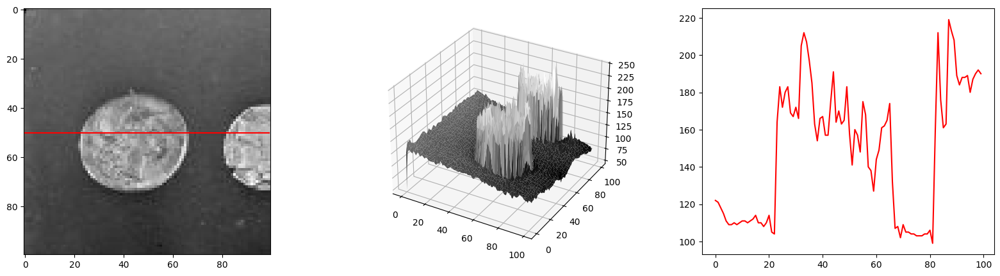

In [5]:
surface = img_coins[:100,:100] #transform.resize(img_coins, (img_coins.shape[0]//5, img_coins.shape[1]//5))
h,w = surface.shape
xx, yy = np.mgrid[0:surface.shape[0], 0:surface.shape[1]]

fig = plt.figure(figsize=(20,5))
ax0 = fig.add_subplot(1, 3, 1)
# Imagen original con scanline resaltada:
ax0.imshow(surface, cmap="gray")
ax0.plot([0,w-1],[h//2,h//2],"r-")
ax1 = fig.add_subplot(1, 3, 2, projection='3d')
# Superficie (surface plot):
ax1.plot_surface(xx, yy, surface, cmap="gray")
ax2 = fig.add_subplot(1, 3, 3)
# Scanline: fila central (h//2):
ax2.plot(surface[h//2,:],"r-")
plt.show()

# Espacios de color

## Imágenes RGB *vs* imágenes de grises / Dominio *vs* rango

Dominio: 512x512
Rango: uint8 (min:0, max:255    |    float64 (min:0.0, max:1.0)


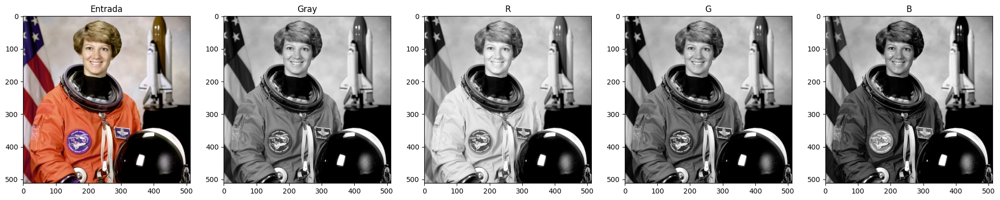

In [6]:
imgGray = color.rgb2gray(img_astronaut)
imgR, imgG, imgB = tuple([img_astronaut[:,:,i] for i in range(3)])
imshow_all(img_astronaut, imgGray, imgR, imgG, imgB, titles=["Entrada","Gray","R","G","B"])
print(f"Dominio: {imgGray.shape[0]}x{imgGray.shape[1]}")
print(f"Rango: {imgR.dtype} (min:{imgR.min()}, max:{imgR.max()}    |    {imgGray.dtype} (min:{imgGray.min()}, max:{imgGray.max()})")

## Espacio YUV

El canal Y equivale a la imagen de luminosidad (escala de grises):

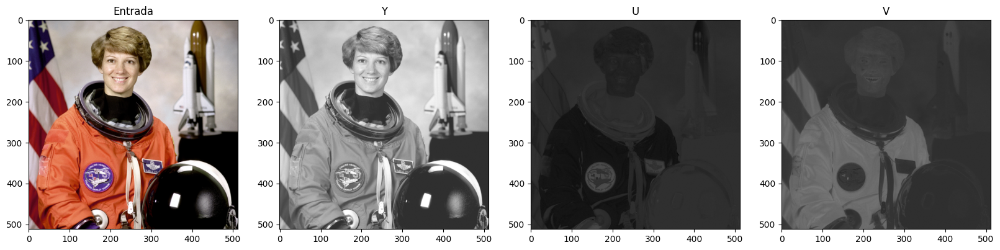

In [7]:
imgYUV = color.rgb2yuv(img_astronaut)
imgY, imgU, imgV = tuple([imgYUV[:,:,i] for i in range(3)])
imshow_all(img_astronaut, imgY, imgU, imgV, titles=["Entrada","Y","U","V"])

## Espacio HSV

El canal H contiene la información de *color*, el S la de *saturación*, y el V la de *valor* ($\simeq$ *luminosidad*, en escala de grises).

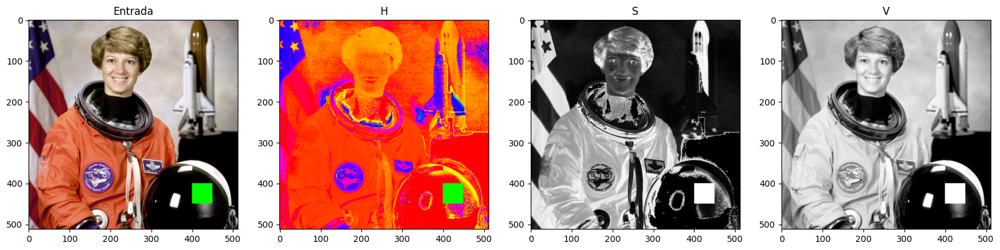

In [8]:
img_astronaut_modified = np.copy(img_astronaut)
img_astronaut_modified[400:450,400:450] = np.array([0,255,0]) # Cuadro verde abajo a la derecha
imgHSV = color.rgb2hsv(img_astronaut_modified)
imgH, imgS, imgV = tuple([imgHSV[:,:,i] for i in range(3)])
imshow_all(img_astronaut_modified, imgH, imgS, imgV, titles=["Entrada","H","S","V"], cmaps=["gray","hsv","gray","gray"])

# Manipulación de histogramas

Se utilizan para estirar el rango dinámico de las imágenes con poco contraste:

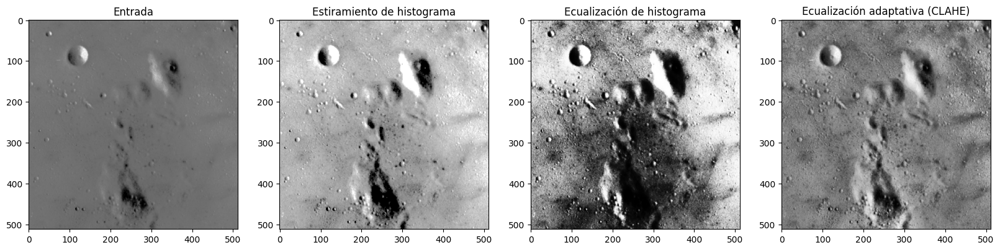

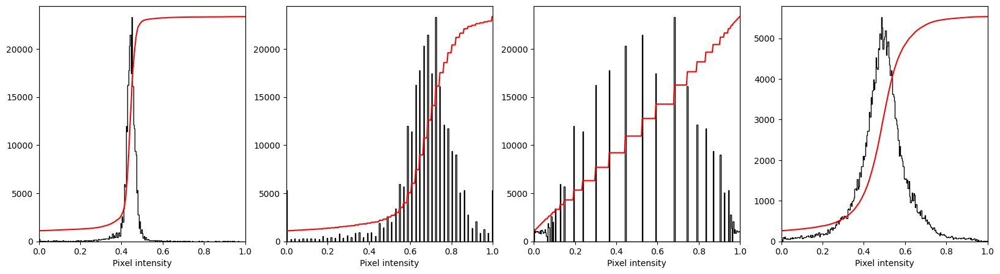

In [9]:
def plot_hist(image, axes, bins=256):
    image = skimage.img_as_float(image)
    ax_cdf = axes.twinx()
    axes.hist(image.ravel(), bins=bins, histtype='step', color='black')
    axes.set_xlabel('Pixel intensity')
    axes.set_xlim(0, 1)
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

# Tres tipos de manipulación, de más sencillo a más elaborado:
# 1. Estiramiento de histograma (stretching):
p2, p98 = np.percentile(img_moon, (2, 98))
img_rescale = exposure.rescale_intensity(img_moon, in_range=(p2, p98))
# 2. Ecualización de histograma:
img_eq = exposure.equalize_hist(img_moon)
# 3. Ecualización adaptativa (CLAHE):
img_adapteq = exposure.equalize_adapthist(img_moon, clip_limit=0.03)

imshow_all(img_moon, img_rescale, img_eq, img_adapteq, titles=["Entrada", "Estiramiento de histograma", "Ecualización de histograma", "Ecualización adaptativa (CLAHE)"])
fig, axes = plt.subplots(1,4,figsize=(20.,5.))
for i,im in enumerate([img_moon, img_rescale, img_eq, img_adapteq]):
  plot_hist(im, axes[i], bins=256)
plt.show();

# Umbralizado

Los filtros de umbralizado se utilizan para binarizar imágenes:

## Umbral de Otsu

Calcula el umbral adaptándose a la luminosidad de la imagen de forma global, buscando el umbral óptimo entre las dos principales modas de la distribución de grises:

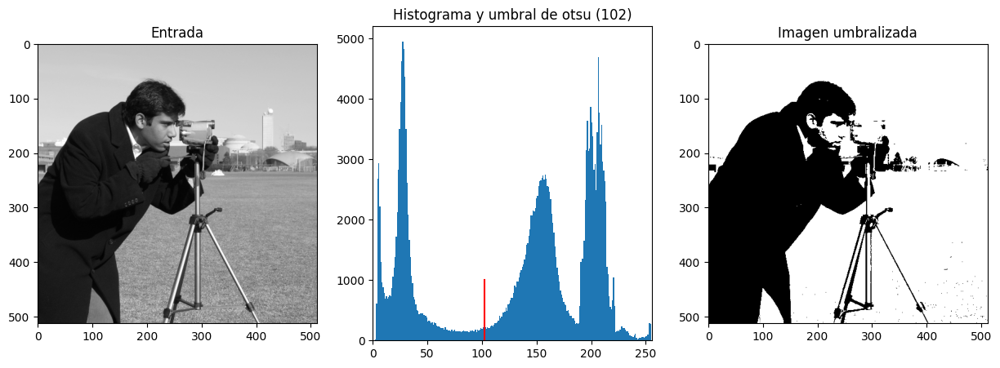

In [10]:
thr_otsu = filters.threshold_otsu(img_camera)
fig, axs = plt.subplots(1, 3, figsize = (15.,5.))
axs[0].imshow(img_camera, cmap="gray")
axs[0].set_title("Entrada")
axs[1].hist(img_camera.ravel(), bins=256, range=[0, 255])
axs[1].set_xlim(0, 256);
axs[1].set_title(f"Histograma y umbral de otsu ({thr_otsu})")
axs[1].plot([thr_otsu, thr_otsu], [0, 1000], 'r-')
axs[2].imshow(img_camera > thr_otsu, cmap="gray")
axs[2].set_title("Imagen umbralizada")
plt.show()

## Umbralizado local

En caso de haber iluminación variable en la escena, suele ser más eficaz emplear un umbralizado local, diferente en cada píxel (en lugar de el mismo para toda la imagen).

Por ejemplo, el valor del umbral se puede tomar como una media de la vecindad local del píxel de entrada, *menos una constante* (esta última útil para evitar la sobresegmentación de zonas "planas" con tono homogéneo de gris):

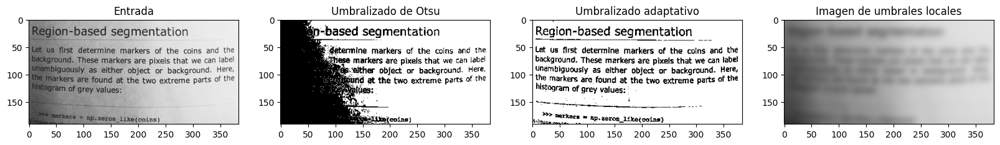

In [11]:
thr_otsu = filters.threshold_otsu(img_page)
img_thr_adapt = filters.threshold_local(img_page, block_size=35, offset=10).astype("uint8")
imshow_all(img_page, img_page > thr_otsu, img_page > img_thr_adapt, img_thr_adapt, titles=["Entrada", "Umbralizado de Otsu", "Umbralizado adaptativo", "Imagen de umbrales locales"])

# Matizado y composición (*matting and compositing*)

Utilizado para la mezcla de imágenes.

En el siguiente *snippet* de código, nótense:
1. La conversión de forma (*reshaping*) de las imágenes monocanal ($shape=(filas,columnas)$) a $shape=(filas,columnas,1)$ con el uso de `np.newaxis`, para poder hacer uso del *broadcasting* automático de `numpy` en la operación de *blending*.
2. La generación de las máscaras como tensores de tipo `uint8` (en lugar de `bool`), para poder realizar la operación entre imágenes del mismo tipo.

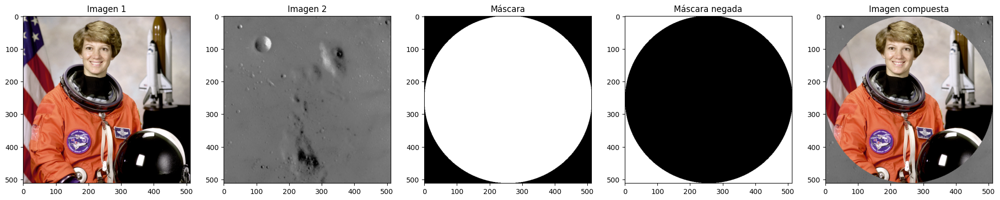

In [12]:
nrows, ncols = tuple(img_moon.shape)
# Matrices de tamaño nrows x ncols, con el índice de fila y de columna en cada posición:
row, col = np.ogrid[:nrows, :ncols]
cnt_row, cnt_col = nrows / 2, ncols / 2
# Conversión de una imagen de tipo bool (máscara) a una entera (tipo uint8):
outer_disk_mask = ((row - cnt_row)**2 + (col - cnt_col)**2 > (nrows / 2)**2).astype("uint8")
inner_disk_mask = (1 - outer_disk_mask)
# Obsérvese el uso de la técnica de broadcasting: hay que añadir np.newaxis a las imágenes
# de un sólo canal (dimensiones (rows, cols), para convertirlas en imágenes de dimensiones
# (rows, cols, 1) y poder combinarlas con la imagen RGB de (dimensión (rows,cols,3)):
img_out = (inner_disk_mask[:,:,np.newaxis] * img_astronaut + outer_disk_mask[:,:,np.newaxis] * img_moon[:,:,np.newaxis])
imshow_all(img_astronaut, img_moon, 255*inner_disk_mask, 255*outer_disk_mask, img_out, titles=["Imagen 1","Imagen 2","Máscara","Máscara negada","Imagen compuesta"])

# Filtros Lineales

## Filtro de media

Ejemplo interactivo ilustrando el funcionamiento de un filtro de media (*mean filter*)

In [13]:
bright_square = np.zeros((7, 7), dtype=float)
bright_square[2:5, 2:5] = 1
mean_filter_interactive_demo(bright_square)
print("Máscara:")
print(np.full((3,3),1/9))

interactive(children=(IntSlider(value=0, description='i_step', max=48), Output()), _dom_classes=('widget-inter…

Máscara:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


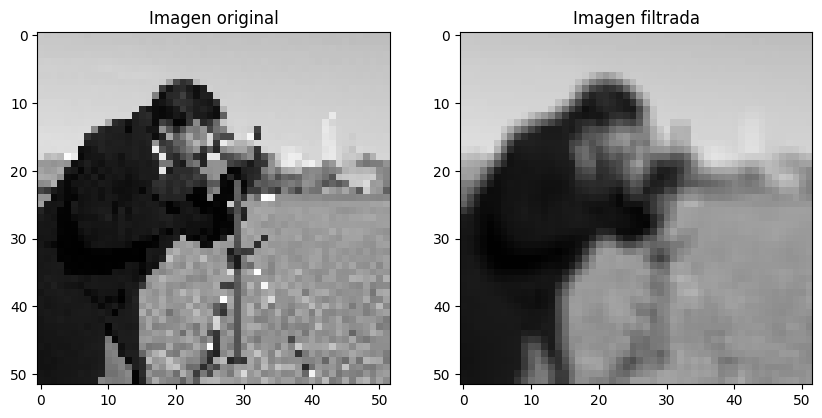

In [14]:
# Construimos imagen pixelada con un simple slicing del array de numpy:
img_pixelated = img_camera[::10, ::10]
img_mean_filtered = ndi.correlate(img_pixelated, np.full((3, 3), 1/9))
imshow_all(img_pixelated, img_mean_filtered, titles=['Imagen original', 'Imagen filtrada'])

## Filtro gaussiano

In [15]:
def plot_gauss_filter(image, sigma):
  impulse = np.zeros((9, 9), dtype=float)
  impulse[4, 4] = 1.0
  gauss_filter = filters.gaussian(impulse, sigma=sigma)
  img_gauss_filtered = filters.gaussian(image, sigma=sigma)
  fig, axs = plt.subplots(1, 3, figsize = (15.,5.))
  axs[0].imshow(image, cmap="gray")
  axs[0].set_title("Original")
  axs[1].imshow(img_gauss_filtered, cmap="gray")
  axs[1].set_title(f"Resultado de filtro gaussiano")
  axs[2].imshow(gauss_filter, cmap="gray")
  axs[2].set_title("Filtro utilizado")
  plt.show();

interact(plot_gauss_filter,
         image=fixed(img_pixelated),
         sigma=FloatSlider(value=1.0,min=1.0,max=2.0, orientation='horizontal', continuous_update=False));


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='sigma', max=2.0, min=1.0), …

Comparación entre filtro de media y filtro gaussiano gaussiano:

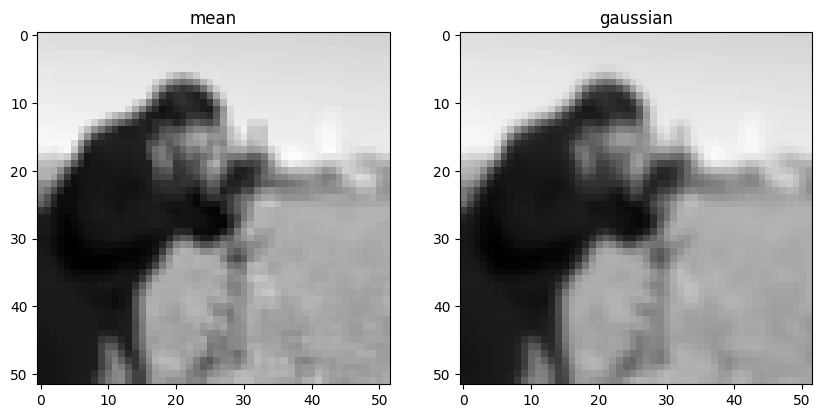

In [16]:
size = 1
structuring_element = np.ones((3*size, 3*size))
smooth_mean = filters.rank.mean(img_pixelated, structuring_element)
smooth_gaussian = filters.gaussian(img_pixelated, sigma=size)
titles = ['mean', 'gaussian']
imshow_all(smooth_mean, smooth_gaussian, titles=titles)

## Filtrado de gradiente

## Roberts *vs* Sobel

Estimaciones de borde proporcionales al **módulo** del gradiente:

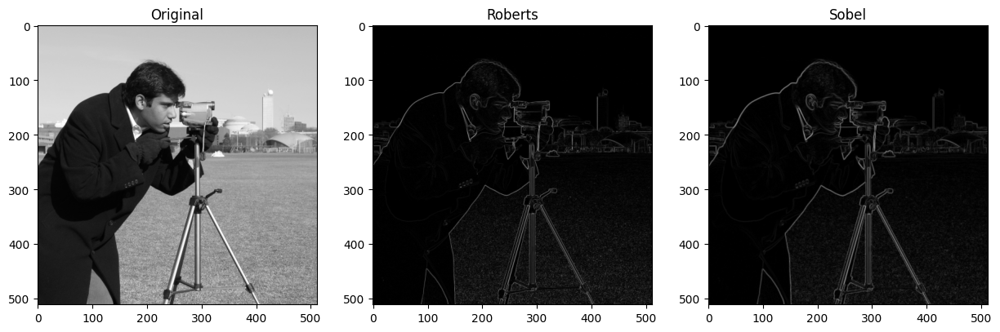

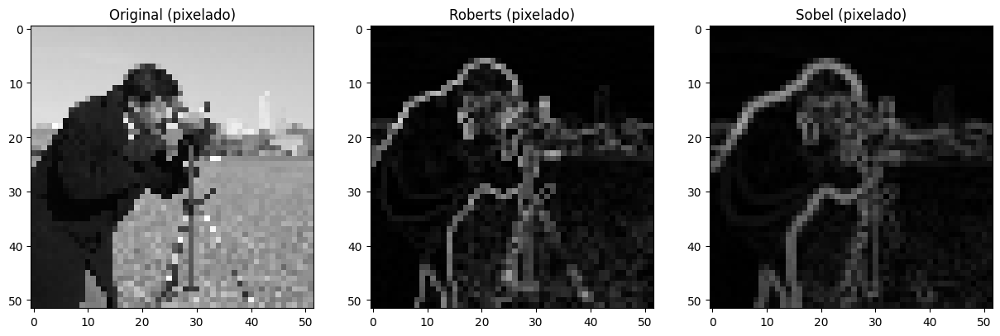

In [17]:
imshow_all(img_camera, filters.roberts(img_camera), filters.sobel(img_camera), titles=["Original", "Roberts", "Sobel"])
imshow_all(img_pixelated, filters.roberts(img_pixelated), filters.sobel(img_pixelated), titles=["Original (pixelado)", "Roberts (pixelado)", "Sobel (pixelado)"])

In [18]:
print("Máscara operador Roberts (X):")
print(np.array([[0,0,0],[-1,0,+1],[0,0,0]]))
print("Máscara operador Roberts (Y):")
print(np.array([[0,-1,0],[0,0,0],[0,+1,0]]))
print("Máscara operador Sobel 3x3 (X):")
print(np.array([[-1,0,+1],[-2,0,+2],[-1,0,+1]]))
print("Máscara operador Sobel 3x3 (Y):")
print(np.array([[-1,-2,-1],[0,0,0],[+1,+2,+1]]))

Máscara operador Roberts (X):
[[ 0  0  0]
 [-1  0  1]
 [ 0  0  0]]
Máscara operador Roberts (Y):
[[ 0 -1  0]
 [ 0  0  0]
 [ 0  1  0]]
Máscara operador Sobel 3x3 (X):
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Máscara operador Sobel 3x3 (Y):
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


## Derivadas direccionales (Sobel X y Sobel Y):

En realidad, el gradiente es un vector bidimensional (lo anterior era una estimación sólo de su módulo). Por tanto, tiene coordenadas X e Y, y apunta en una dirección.

Obsérvese, también, por tanto, que las componentes de ese vector pueden ser positivas o negativas (de ahí que al dibujarlo, aparezca en gris el valor 0, en blanco los valores más positivos, y en negro los más negativos).

Rango entrada: uint8 (min:3, max:255)   |    Rango salida: float64 (min:-0.7264705882352942, max:0.5784313725490196)


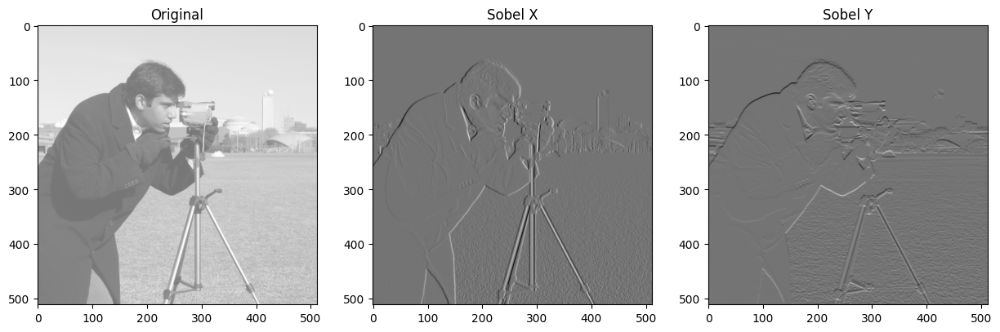

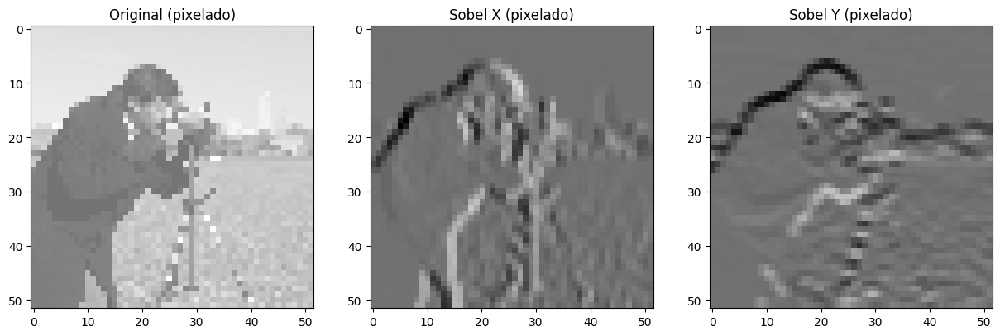

In [19]:
img_sob_h = filters.sobel_h(img_camera)
img_sob_v = filters.sobel_v(img_camera)
img_sob_h_pixelated = filters.sobel_h(img_pixelated)
img_sob_v_pixelated = filters.sobel_v(img_pixelated)
imshow_all(img_camera, img_sob_v, img_sob_h, titles=["Original", "Sobel X", "Sobel Y"])
imshow_all(img_pixelated, img_sob_v_pixelated, img_sob_h_pixelated, titles=["Original (pixelado)", "Sobel X (pixelado)", "Sobel Y (pixelado)"])
print(f"Rango entrada: {img_pixelated.dtype} (min:{img_pixelated.min()}, max:{img_pixelated.max()})   |    Rango salida: {img_sob_h_pixelated.dtype} (min:{img_sob_h_pixelated.min()}, max:{img_sob_h_pixelated.max()})")

He aquí la misma información, mostrando los gradientes en cada píxel como los verdaderos vectores que son:

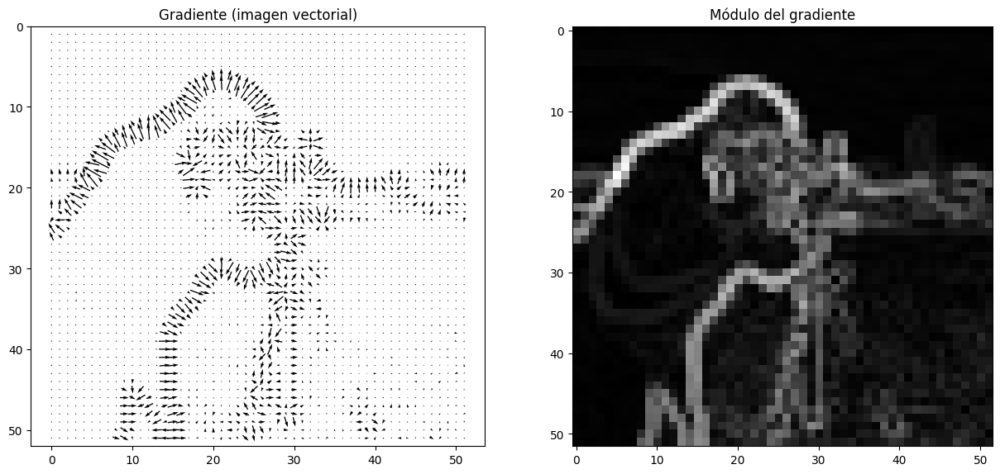

In [20]:
w, h = img_pixelated.shape
x = np.arange(0, w)
y = np.arange(0, h)
X, Y = np.meshgrid(x, y)
u = img_sob_v_pixelated
v = img_sob_h_pixelated

fig, axs = plt.subplots(1, 2, figsize =(15,30), gridspec_kw={'width_ratios': [1.08, 1]})
axs[0].quiver(X, Y, u, v, angles="xy", pivot="middle", scale=20.0)
axs[0].set_aspect('equal')
axs[0].set_ylim(h,0)
axs[0].set_ylim(w,0)
axs[0].set_title("Gradiente (imagen vectorial)")
axs[1].imshow(filters.sobel(img_pixelated),cmap="gray")
axs[1].set_title("Módulo del gradiente")
plt.show()

## Filtros de Gabor

El filtro de Gabor es un filtro lineal cuya respuesta de impulso es una función sinusoidal, multiplicada por una función gaussiana ([enlace](https://medium.com/@anuj_shah/through-the-eyes-of-gabor-filter-17d1fdb3ac97)).

Son utilizados sobre todo en clasificación de texturas.

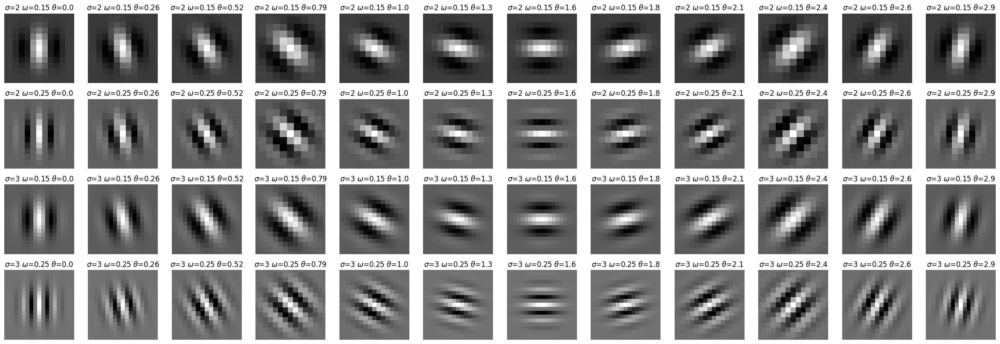

In [21]:
sigmas = [2, 3]
frequencies = [0.15, 0.25]
nangles = 12
angles = [theta*np.pi / nangles for theta in range(nangles)]
rows = len(sigmas)*len(frequencies)
cols = len(angles)
fig, axs = plt.subplots(rows, cols, figsize=(cols*2.5,rows*2.5))
kernels = []
row = 0
for sigma in sigmas:
  for omega in frequencies:
    col = 0
    for theta in angles:
      # Nótese que nos quedamos sólo con la parte real:
      kernel = np.real(filters.gabor_kernel(omega, theta=theta, sigma_x=sigma, sigma_y=sigma))
      kernels.append(kernel)
      axs[row,col].imshow(kernel, cmap="gray")
      axs[row,col].set_xlim((0,kernel.shape[0]-1))
      axs[row,col].set_ylim((0,kernel.shape[0]-1))
      axs[row,col].set_axis_off()
      axs[row,col].set_title(fr"$\sigma$={sigma} $\omega$={omega:.2} $\theta$={theta:.2}")
      col += 1
    row += 1

# Filtros no lineales

## Filtrado de mediana

Suelen usarse para eliminar ruido, pero son mejores que los lineales (p.e. media o gaussiana) para respetar los bordes:

Elemento estructural 'disco':
[[0 1 0]
 [1 1 1]
 [0 1 0]]
Elemento estructural 'cuadrado':
[[1 1 1]
 [1 1 1]
 [1 1 1]]


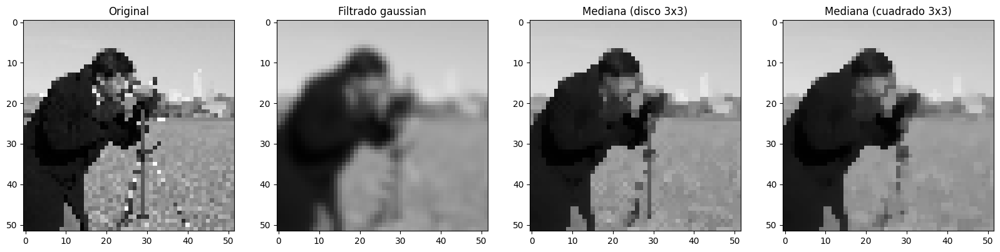

In [22]:
radius = 1
neighborhood_disk = morphology.disk(radius=radius)
neighborhood_square = np.full((3,3),1,dtype="uint8")
img_median_disk = filters.rank.median(img_pixelated, neighborhood_disk)
img_median_square = filters.rank.median(img_pixelated, neighborhood_square)
img_smooth = filters.gaussian(img_pixelated, sigma=size)
titles = ['Original', 'Filtrado gaussian', 'Mediana (disco 3x3)', 'Mediana (cuadrado 3x3)']
imshow_all(img_pixelated, img_smooth, img_median_disk, img_median_square, titles=titles)
print("Elemento estructural 'disco':")
print(neighborhood_disk)
print("Elemento estructural 'cuadrado':")
print(neighborhood_square)

Comportamiento con ruido de tipo "sal y pimienta" acusado:

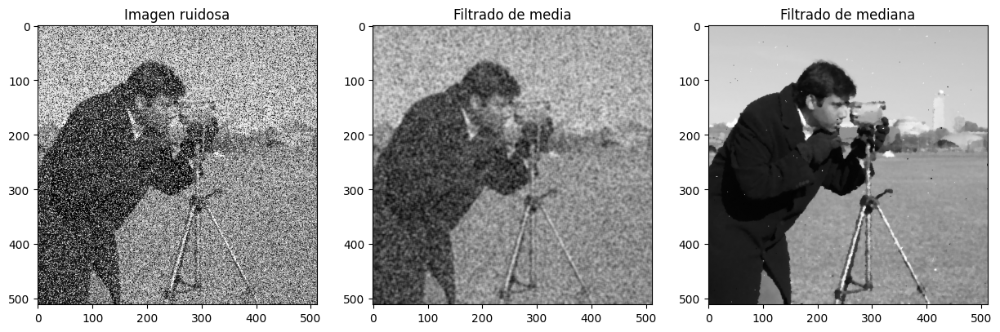

In [23]:
size = 5
neighborhood_square = np.full((size,size), 1, dtype="uint8")
noise = np.random.rand(*img_camera.shape)
img_noisy = img_camera.copy()
img_noisy[noise > 0.8] = 255
img_noisy[noise < 0.2] = 0
mean_noisy = filters.rank.mean(img_noisy, neighborhood_square)
median_noisy = filters.rank.median(img_noisy, neighborhood_square)
imshow_all(img_noisy, mean_noisy, median_noisy, titles=['Imagen ruidosa', 'Filtrado de media', 'Filtrado de mediana'])

## Filtrado bilateral

Mezcla las buenas propiedades del filtrado no lineal (respetar los bordes) y del lineal (suavizar sin aplanar demasiado), al precio de ser *bastante* más lento.

Se promedian sólo los píxeles que entran en un intervalo $[v-s_0,v+s_1]$, y en un ámbito espacial dado por la máscara (disco de radio dado), para cada píxel con valor inicial $v$:

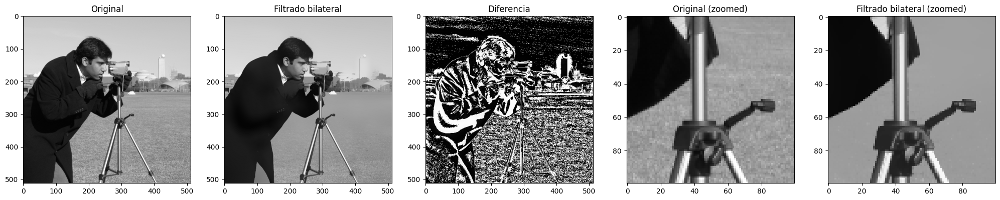

In [24]:
radius=20
img_bilateral = filters.rank.mean_bilateral(img_camera, morphology.disk(radius), s0=30, s1=30)
imshow_all(img_camera, img_bilateral, img_camera-img_bilateral, img_camera[250:350,250:350], img_bilateral[250:350,250:350],
           titles=['Original', 'Filtrado bilateral', 'Diferencia', 'Original (zoomed)', 'Filtrado bilateral (zoomed)'])

## Operaciones morfológicas

Utilizadas sobre todo en imágenes binarias (tras algún tipo de umbralizado / segmentación), para eliminar zonas aisladas pequeñas. Hay variantes para eliminar tanto zonas blancas rodeadas de negro -erosión, apertura- como zonas blancas rodeadas de negro -dilatación, cierre-.

Se definen también, por extensión, las mismas operaciones morfológicas sobre imágenes niveles de gris (usando el máximo y el mínimo de los valores dentro de la máscara local, en lugar de 1/0).

Cuadrado:
 [[1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]]
Diamante:
 [[0 0 0 0 1 0 0 0 0]
 [0 0 0 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 0 0 0]
 [0 0 0 0 1 0 0 0 0]]


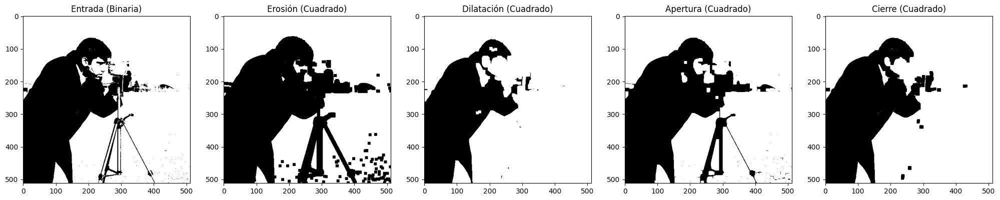

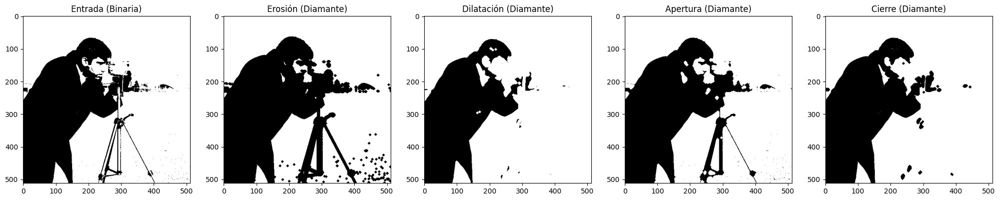

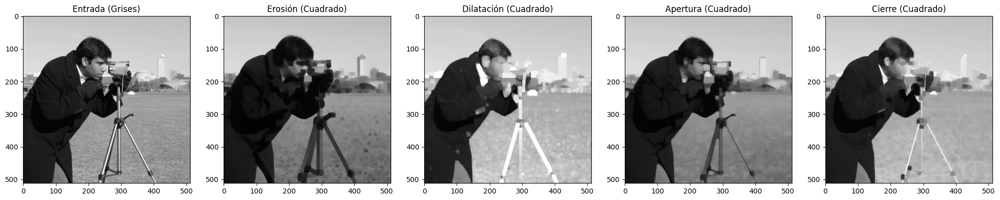

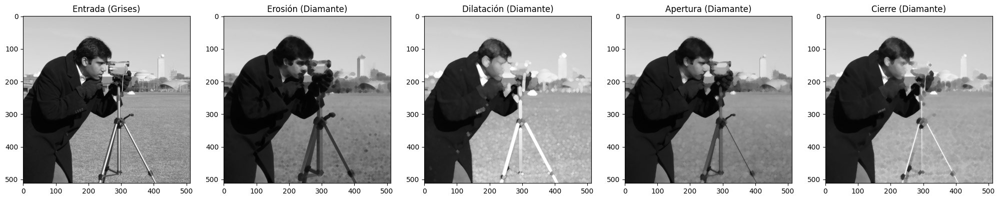

In [25]:
square = morphology.footprint_rectangle((9,9))
diamond = morphology.diamond(radius=4)
print("Cuadrado:\n",square)
print("Diamante:\n",diamond)
for img, bin_str in zip([img_camera>100, img_camera],["Binaria","Grises"]):
  for selem, selem_str in zip([square, diamond],["Cuadrado","Diamante"]):
    imshow_all(img, morphology.erosion(img, selem), morphology.dilation(img, selem), morphology.opening(img, selem), morphology.closing(img, selem),
               titles=["Entrada"+" ("+bin_str+")"] + list(map(lambda x: x+" ("+selem_str+")", ["Erosión", "Dilatación", "Apertura", "Cierre"])))

# Transformada de distancia

Para cada píxel, dan la distancia (euclídea / Manhattan) al píxel más cercano considerado "activo". En estos ejemplos, consideramos como activos los píxeles con valor 0 (negros):

/tmp/ipython-input-3079265816.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  img_horse_silhouette = np.copy(255-img_horse-255*morphology.erosion(img_horse, morphology.square(3)))


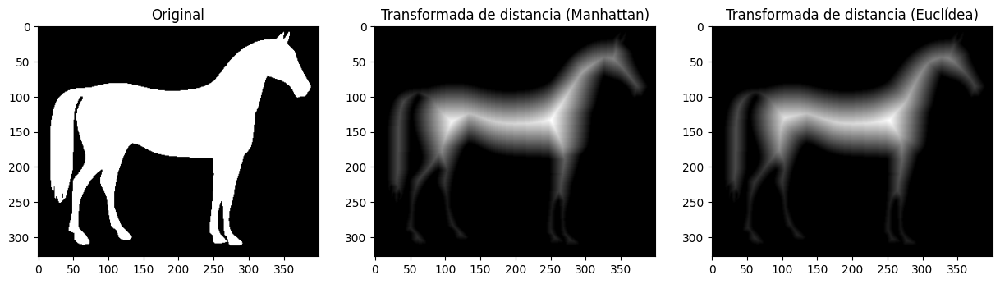

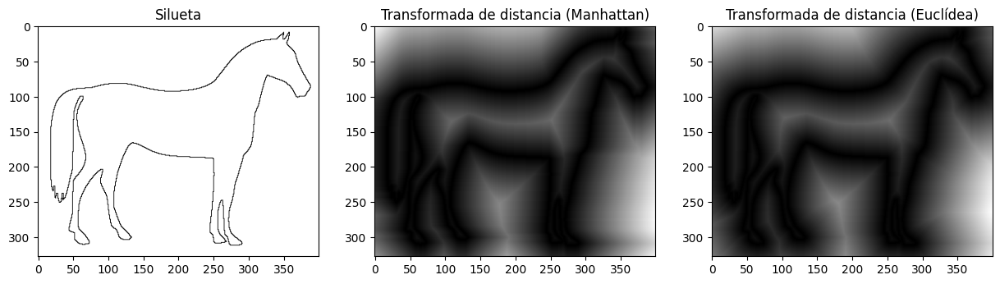

In [26]:
img_horse = (1-skimage.data.horse().astype("uint8"))*255
# Obsérvese el uso de la resta de la imagen erosionada al negativo de la original para
# calcular la silueta:
img_horse_silhouette = np.copy(255-img_horse-255*morphology.erosion(img_horse, morphology.square(3)))
dist_L1 = cv2.distanceTransform(img_horse, cv2.DIST_L1, 3)
dist_L2 = cv2.distanceTransform(img_horse, cv2.DIST_L2, 3)
dist_L1_silhouette = cv2.distanceTransform(img_horse_silhouette, cv2.DIST_L1, 3)
dist_L2_silhouette = cv2.distanceTransform(img_horse_silhouette, cv2.DIST_L2, 3)

# Normalizamos distancias al rango [0.0,1.0] para visualizarlas:
cv2.normalize(dist_L1, dist_L1, 0, 1.0, cv2.NORM_MINMAX)
cv2.normalize(dist_L2, dist_L2, 0, 1.0, cv2.NORM_MINMAX)
cv2.normalize(dist_L1_silhouette, dist_L1_silhouette, 0, 1.0, cv2.NORM_MINMAX)
cv2.normalize(dist_L2_silhouette, dist_L2_silhouette, 0, 1.0, cv2.NORM_MINMAX)

imshow_all(img_horse, dist_L1, dist_L2, titles=["Original", "Transformada de distancia (Manhattan)", "Transformada de distancia (Euclídea)"])
imshow_all(img_horse_silhouette, dist_L1_silhouette, dist_L2_silhouette, titles=["Silueta", "Transformada de distancia (Manhattan)", "Transformada de distancia (Euclídea)"])

# Componentes conexas

Aislan zonas de píxeles conectados, típicamente sobre imágenes binarizadas:

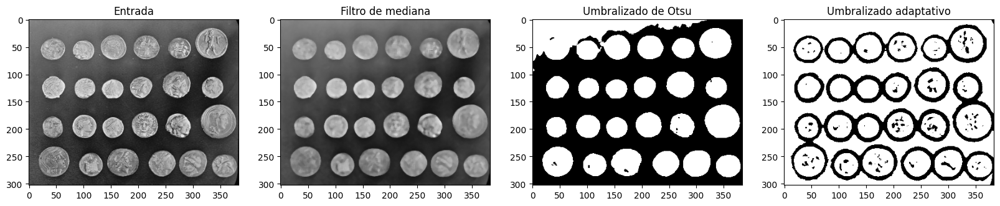

In [27]:
# Filtrado previo con mediana 5x5, seguido de un umbralizado (en este caso, mejor adaptativo):
neighborhood_square = np.full((5,5), 1, dtype="uint8")
img_median = filters.rank.median(img_coins, neighborhood_square)
thr_otsu = filters.threshold_otsu(img_median)
img_thr_adapt = filters.threshold_local(img_median, block_size=35, offset=10).astype("uint8")
imshow_all(img_coins, img_median, img_median > thr_otsu, img_median > img_thr_adapt, titles=["Entrada", "Filtro de mediana", "Umbralizado de Otsu", "Umbralizado adaptativo"])

 Para cada componente, se suelen computar sus respectivos *bounding boxes*, centros y áreas. También se devuelve una imagen con los números de etiqueta (=número diferente para cada componente). Una explicación rápida de la forma en que se devuelven esos valores se puede encontrar [aquí](https://stackoverflow.com/questions/35854197/how-to-use-opencvs-connectedcomponentswithstats-in-python):

Número de componentes = 31 en total, 24 seleccionados por área.


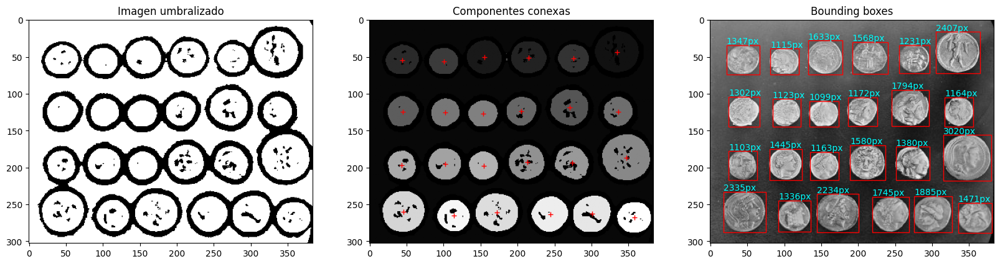

In [28]:
bin_coins = (img_median>img_thr_adapt).astype("uint8")
ccs = cv2.connectedComponentsWithStats(bin_coins, connectivity=4)
areas = np.array([cc[-1] for cc in ccs[2]])
# Seleccionamos sólo aquellas componentes con un área plausible para nuestro problema:
select_ccs = np.logical_and(1000 < areas, areas < 5000)
print(f"Número de componentes = {ccs[0]} en total, {np.sum(select_ccs)} seleccionados por área.")
# print(f"Áreas de los componentes (en píxeles) = {areas}")
fig, axs = plt.subplots(1,3,figsize=(20,60))
axs[0].imshow(bin_coins,cmap="gray")
axs[0].set_title("Imagen umbralizado")
axs[1].imshow(ccs[1],cmap="gray")
axs[1].plot(ccs[3][select_ccs][:,0],ccs[3][select_ccs][:,1],"r+")
axs[1].set_title("Componentes conexas")
axs[2].imshow(img_coins,cmap="gray")
axs[2].set_title("Bounding boxes")
bounding_boxes = ccs[2][select_ccs][:,:-1]
for area, bb in zip(areas[select_ccs], bounding_boxes):
    axs[2].add_patch(Rectangle((bb[0], bb[1]), bb[2], bb[3], edgecolor='red', fill=False))
    axs[2].text(bb[0], bb[1]-2, f"{area}px", color='cyan')

# Pirámides de imagen

Se calculan una serie de imágenes subescaladas a partir de la imagen original. Antes de cada submuestreado, se realiza un filtrado gaussiano para evitar el efecto de *aliasing* (Moiré).

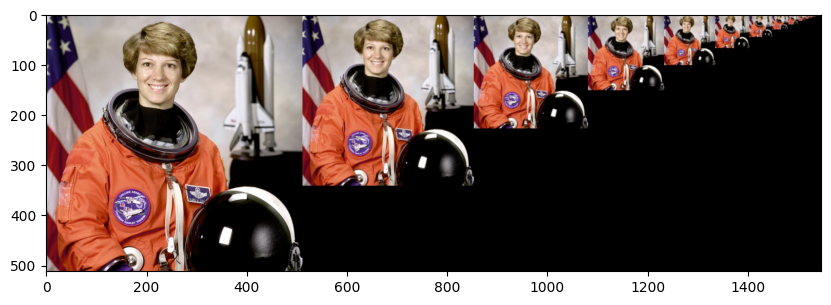

In [29]:
rows, cols, dim = img_astronaut.shape
pyramid = tuple(transform.pyramid_gaussian(img_astronaut, downscale=1.5, channel_axis=-1))

# Suma de los tamaños horizontales de toda la pirámide:
cum_cols = 0
for p in pyramid:
    _, n_cols = p.shape[:2]
    cum_cols += n_cols

# Imagen compuesta:
composite_image = np.zeros((rows, cum_cols, 3), dtype=np.double)
composite_image[:rows, :cols, :] = pyramid[0]
i_row = 0
cum_cols = 0
for p in pyramid[1:]:
    n_rows, n_cols = p.shape[:2]
    composite_image[:n_rows, cols+cum_cols:cols +cum_cols+ n_cols] = p
    i_row += n_rows
    cum_cols += n_cols

fig, ax = plt.subplots(figsize=(10,20))
ax.imshow(composite_image)
plt.show()

# Transformaciones geométricas

Utilizadas para cambiar el *dominio* de la imagen (en lugar del rango). Con ello, se logran distintos tipos de deformaciones sobre la misma.

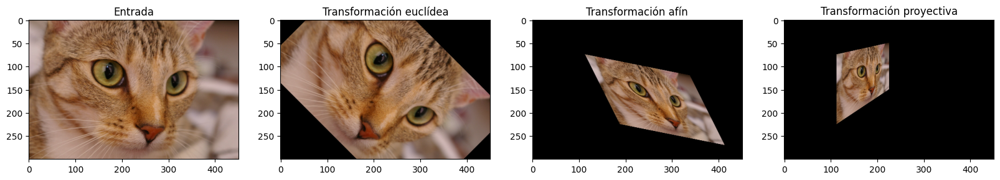

In [32]:
h,w,_ = tuple(img_chelsea.shape)

# Transformación compuesta (primero trasladar centro imagen al origen, despues
# escalar, rotar, y trasladar de vuelta al centro de la imagen):
tform1 = transform.SimilarityTransform(
    transform.SimilarityTransform(scale=1, rotation=math.pi/4, translation=(+w/2, +h/2)).params
    @
    transform.SimilarityTransform(translation=(-w/2, -h/2)).params )

# Transformación manual (proporcionando directamente matriz de homografía 3x3).
# En este caso se trata de una transformación afín (elementos [0,1] y/o [1,0]
# distintos de cero):
matrix = np.array([[0.5, 0.25, w/4],
                   [0.1, 0.5, h/4],
                   [0.0, 0.0, 1.0]])
tform2 = transform.EuclideanTransform(matrix)

# Transformación manual (proporcionando directamente matriz de homografía 3x3).
# Nótese que en este caso la tercera fila es diferente de (0,0,1) -> habrá
# transformación proyectiva (puntos de fuga):
matrix = np.array([[0.5, 0.0, w/4],
                   [0.0, 0.5, h/4],
                   [0.5/w, 0.0, 1.0]])
tform3 = transform.ProjectiveTransform(matrix)

tf1_img = transform.warp(img_chelsea, tform1.inverse, mode='constant') # 'symmetric', 'reflect', 'wrap'
tf2_img = transform.warp(img_chelsea, tform2.inverse)
tf3_img = transform.warp(img_chelsea, tform3.inverse)
imshow_all(img_chelsea, tf1_img, tf2_img, tf3_img, titles=["Entrada", "Transformación euclídea", "Transformación afín", "Transformación proyectiva"])

Matriz de transformación homográfica H estimada (3x3):
[[ 4.67219589e-01 -1.85339652e+00  1.55000000e+02]
 [ 2.09636651e-01  4.67140600e-01  1.50000000e+01]
 [-6.00315956e-04 -8.21484992e-04  1.00000000e+00]]


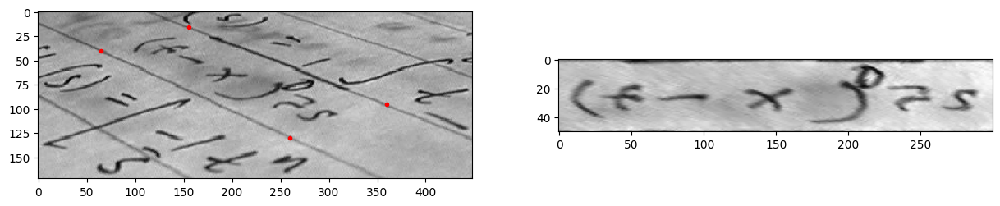

In [31]:
# Estimación de transformación homográfica a partir de 4 correspondencias de puntos:
src = np.array([[0, 0], [0, 50], [300, 50], [300, 0]])
dst = np.array([[155, 15], [65, 40], [260, 130], [360, 95]])

tform3 = transform.ProjectiveTransform()
tform3.estimate(src, dst)
warped = transform.warp(img_text, tform3, output_shape=(50, 300))
print("Matriz de transformación homográfica H estimada (3x3):")
print(tform3.params)

fig, ax = plt.subplots(1,2,figsize=(15, 5))
ax[0].imshow(img_text, cmap=plt.cm.gray)
ax[0].plot(dst[:, 0], dst[:, 1], '.r')
ax[1].imshow(warped, cmap=plt.cm.gray)
plt.show()